In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pickle

In [2]:
df = pd.read_csv('../datasets/yield_df.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (28242, 8)

Columns: ['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [3]:
# Drop the blank first column (row number column)
df = df.drop(columns=[col for col in df.columns if 'Unnamed' in col])
print("Shape after dropping unnamed column:", df.shape)
print("Columns now:", df.columns.tolist())

Shape after dropping unnamed column: (28242, 7)
Columns now: ['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [5]:
# Drop rows where yield or crop name is missing (critical columns)
df = df.dropna(subset=['hg/ha_yield', 'Item'])

# Fill missing rainfall with median
df['average_rain_fall_mm_per_year'] = df['average_rain_fall_mm_per_year'].fillna(df['average_rain_fall_mm_per_year'].median())

# Fill missing temperature with median
df['avg_temp'] = df['avg_temp'].fillna(df['avg_temp'].median())

# Fill missing pesticides with median
df['pesticides_tonnes'] = df['pesticides_tonnes'].fillna(df['pesticides_tonnes'].median())

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [6]:
print("Total duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Total duplicate rows: 2310
After removing duplicates: (25932, 7)


In [7]:
df['Area'] = df['Area'].str.strip().str.title()
df['Item'] = df['Item'].str.strip().str.title()

print("Unique Countries/Areas:", df['Area'].nunique())
print("\nUnique Crops:", df['Item'].nunique())
print("\nCrop names:")
print(sorted(df['Item'].unique()))

Unique Countries/Areas: 101

Unique Crops: 10

Crop names:
['Cassava', 'Maize', 'Plantains And Others', 'Potatoes', 'Rice, Paddy', 'Sorghum', 'Soybeans', 'Sweet Potatoes', 'Wheat', 'Yams']


In [8]:
df.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000
mean,2001.556455,76978.132925,1146.836688,34782.573241,20.422251
std,7.055924,84647.605552,717.391098,57228.568244,6.439402
min,1990.000000,50.000000,51.000000,0.040000,1.300000
25%,1995.000000,19996.000000,593.000000,1597.000000,16.580000
50%,2001.000000,39530.000000,1083.000000,15373.000000,21.420000
75%,2008.000000,104168.000000,1668.000000,45620.000000,26.060000
max,2013.000000,501412.000000,3240.000000,367778.000000,30.650000


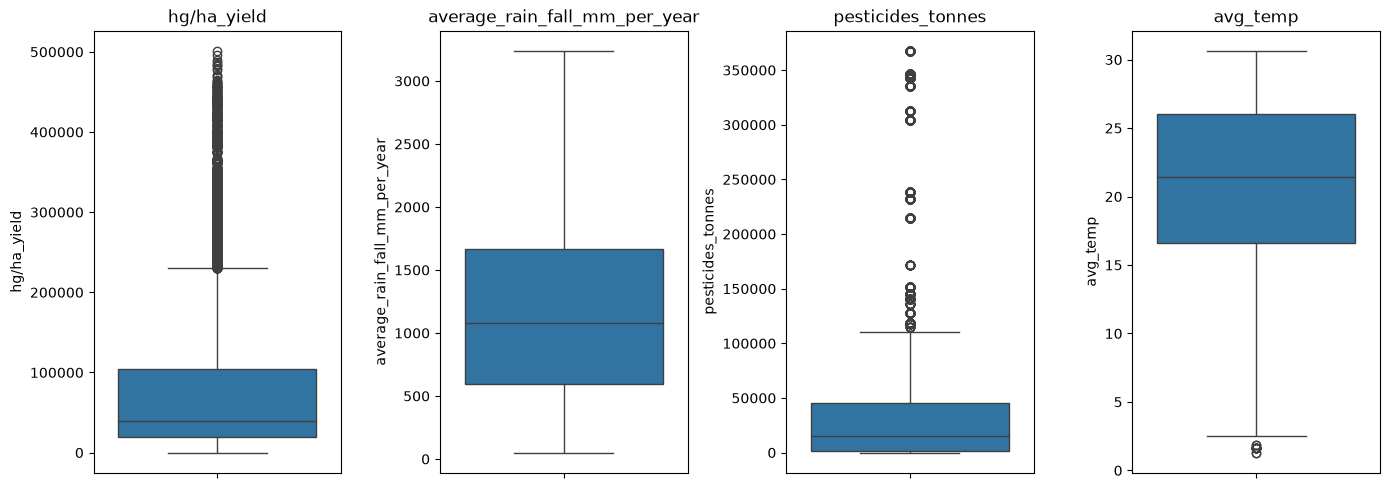

In [9]:
features = ['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

plt.figure(figsize=(14, 5))
for i, col in enumerate(features):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [10]:
# Remove physically impossible values
df = df[df['hg/ha_yield'] > 0]
df = df[df['average_rain_fall_mm_per_year'] >= 0]
df = df[df['pesticides_tonnes'] >= 0]
df = df[df['avg_temp'].between(-10, 60)]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (25932, 7)


In [11]:
df = df.rename(columns={
    'Item': 'crop',
    'Area': 'country',
    'hg/ha_yield': 'yield_hg_per_ha',
    'average_rain_fall_mm_per_year': 'rainfall_mm',
    'pesticides_tonnes': 'pesticides_tonnes',
    'avg_temp': 'avg_temp',
    'Year': 'year'
})

print("New column names:", df.columns.tolist())

New column names: ['country', 'crop', 'year', 'yield_hg_per_ha', 'rainfall_mm', 'pesticides_tonnes', 'avg_temp']


In [13]:
# Encode crop names
le_yield_crop = LabelEncoder()
df['crop_encoded'] = le_yield_crop.fit_transform(df['crop'])

# Encode country names
le_country = LabelEncoder()
df['country_encoded'] = le_country.fit_transform(df['country'])

print("Total crops encoded:", len(le_yield_crop.classes_))
print("Total countries encoded:", len(le_country.classes_))

# Save encoders
pickle.dump(le_yield_crop, open('../models/yield_crop_encoder.pkl', 'wb'))
pickle.dump(le_country, open('../models/country_encoder.pkl', 'wb'))

print("\nEncoders saved!")

Total crops encoded: 10
Total countries encoded: 101

Encoders saved!


In [12]:
df.to_csv('../datasets/cleaned_yield.csv', index=False)
print("Cleaned yield dataset saved!")
print("Final shape:", df.shape)
df.head()

Cleaned yield dataset saved!
Final shape: (25932, 7)


,country,crop,year,yield_hg_per_ha,rainfall_mm,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, Paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [14]:
verify = pd.read_csv('../datasets/cleaned_yield.csv')
print("Verified saved file shape:", verify.shape)
print("Columns:", verify.columns.tolist())

Verified saved file shape: (25932, 7)
Columns: ['country', 'crop', 'year', 'yield_hg_per_ha', 'rainfall_mm', 'pesticides_tonnes', 'avg_temp']
